<a href="https://colab.research.google.com/github/AshleyH2026/A02-eda-and-visualization/blob/main/notebook_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ashley Hughes

**Date:** 9/10/2026

Foreign Gift Amount Histogram: 



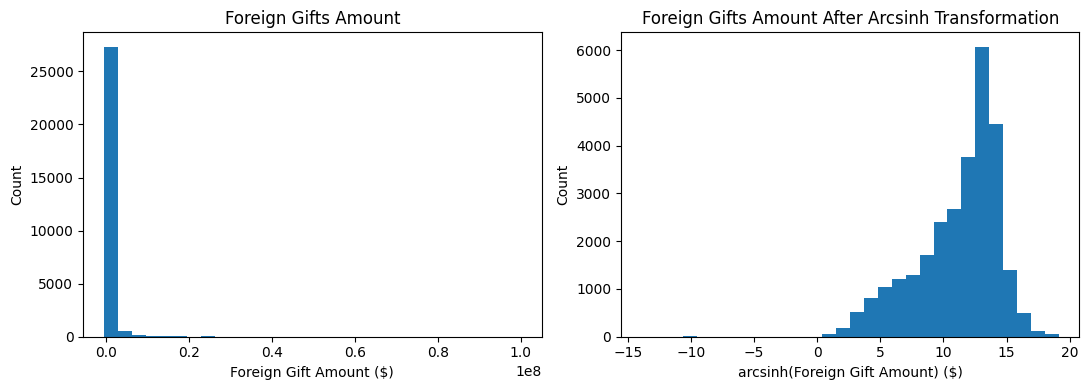



Maximum singular gift amount: 99999999
Minimum singular gift amount: -537770


,mean,median,mode,Q1,Q3
0,588232.717,94615.0,100,5700.0,376142.0


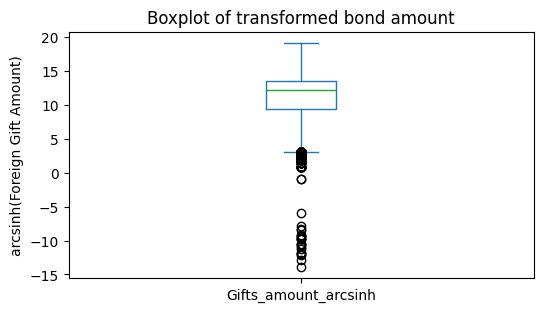




Foreign Gift Amount Variable Description: 
This histogram describes the amount of money spent on gifts (x-axis) and how many times that much money was spent (y-axis).


Foreign Gift Amount Variable Findings:

The histogram displays a left-skewed curve, indicating that there was a higher count for instances of more money being spent on gifts.
The curve peaks around 600k spent (arcsinh(600k) roughly equals 14), with there being around 6000 instances of that much being spent.
Looking at the boxplot, we see the average amount of money spent was $588,232.717, the middle of the distribution for money spent was $946,15.0,
and 75% of the amount of money spent lies between $5700.0 and $376142.0 (IQR).
There were, however, many outliers. With some abnormally small amounts being spent on gifts, including negative amounts being spent in some cases.
These outliers likely lowered the mean, and could have contributed to the mean being lower than the median.
The maximum gift amount was $99999999.



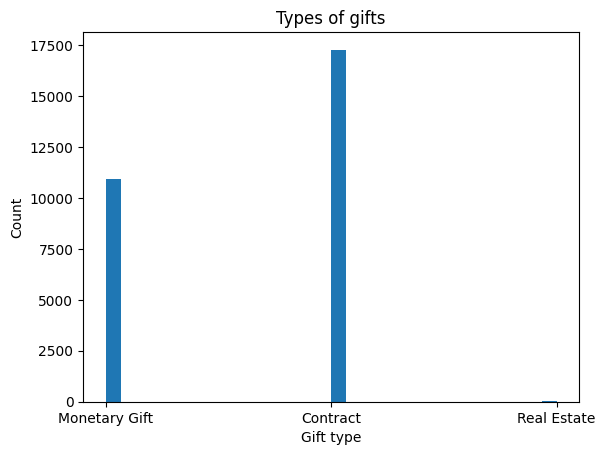




KDE plot of log of foreign gift amount:



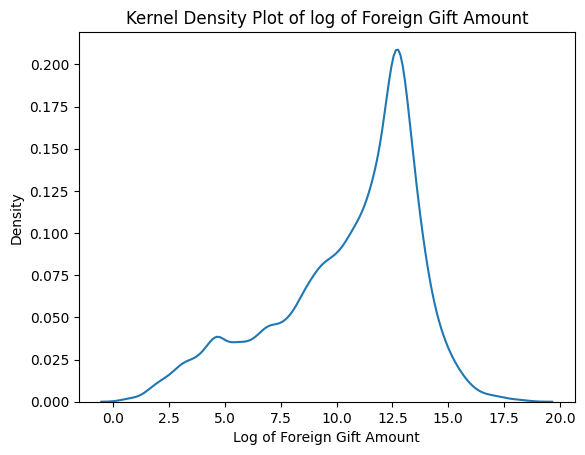




KDE plot of log of foreign gift amount conditional on gift type:



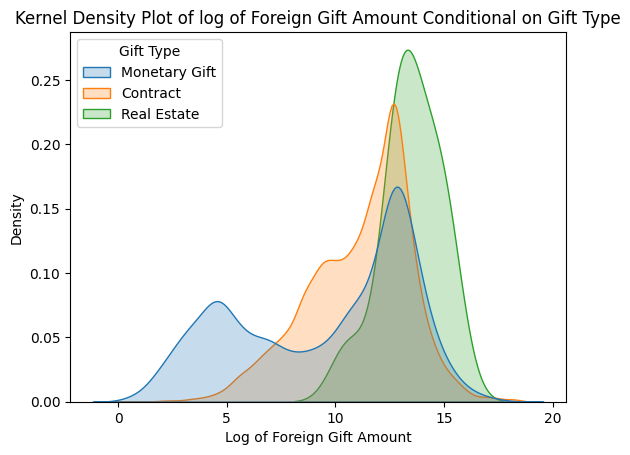




Patterns observed:

Though there weren't many gifts in the form of real estate, real estate gift types typically related to a higher amount of money spent.
While most monetary and contract gifts also had a higher amount spent (relatively close behind the peak for real estate expenses),
these gift types also had a fair amount of instances where lower amounts of money was spent - unlike the real estate type.
Monetary gifts were the most likely to have lower amount spent on gifts, with the plot showing a mini peak around $45 (arcsinh(45) = 4.5)



Top 15 countries in terms of number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: in

In [5]:
# Your Phase 1 solution to the problem goes here.

# Q1 response is uploaded to Github repository

# Q2 Responses

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_gifts = pd.read_csv('ForeignGifts_edu.csv')


# Q2.2 - Foreign Gift Amount Histogram, variable description, and findings.

print("Foreign Gift Amount Histogram: \n")

gifts_amount = df_gifts['Foreign Gift Amount']
# Used arcsinh scale for gifts_amount because histogram has a long tail
df_gifts['Gifts_amount_arcsinh'] = np.arcsinh(df_gifts['Foreign Gift Amount'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
gifts_amount.hist(bins=30, grid=False, ax=axes[0])
axes[0].set(title="Foreign Gifts Amount", xlabel="Foreign Gift Amount ($)", ylabel="Count")
df_gifts['Gifts_amount_arcsinh'].hist(bins=30, grid=False, ax=axes[1])
axes[1].set(title="Foreign Gifts Amount After Arcsinh Transformation", xlabel="arcsinh(Foreign Gift Amount) ($)", ylabel="Count")
plt.tight_layout()
plt.show()

print('\n')

amt_summary = pd.DataFrame({
    "mean": [df_gifts["Foreign Gift Amount"].mean()],
    "median": [df_gifts["Foreign Gift Amount"].median()],
    "mode": [df_gifts["Foreign Gift Amount"].mode().iloc[0]],
    "Q1": [df_gifts["Foreign Gift Amount"].quantile(0.25)],
    "Q3": [df_gifts["Foreign Gift Amount"].quantile(0.75)],
})
print('Maximum singular gift amount: ' + str(df_gifts["Foreign Gift Amount"].max()))
print('Minimum singular gift amount: ' + str(df_gifts["Foreign Gift Amount"].min()))
display(amt_summary.round(3))
df_gifts["Gifts_amount_arcsinh"].plot.box(figsize=(6, 3.2))
plt.title("Boxplot of transformed bond amount")
plt.ylabel("arcsinh(Foreign Gift Amount)")
plt.show()

print('\n')

print("\nForeign Gift Amount Variable Description: \nThis histogram describes the amount of money spent on gifts (x-axis) and how many times that much money was spent (y-axis).\n")

print("""
Foreign Gift Amount Variable Findings:
\nThe histogram displays a left-skewed curve, indicating that there was a higher count for instances of more money being spent on gifts.
The curve peaks around 600k spent (arcsinh(600k) roughly equals 14), with there being around 6000 instances of that much being spent.
Looking at the boxplot, we see the average amount of money spent was $588,232.717, the middle of the distribution for money spent was $946,15.0,
and 75% of the amount of money spent lies between $5700.0 and $376142.0 (IQR).
There were, however, many outliers. With some abnormally small amounts being spent on gifts, including negative amounts being spent in some cases.
These outliers likely lowered the mean, and could have contributed to the mean being lower than the median.
The maximum gift amount was $99999999.

""")

print('\n')

# Q2.3 - Gift Type histogram/value counts table. Proportions of gifts
print('Gift Type value counts table with proportions:\n')
gift_types = df_gifts['Gift Type'].value_counts(normalize = True)
print(gift_types)
print('\n')
print('Gift Type Histogram:\n')
df_gifts['Gift Type'].hist(bins=30, grid=False)
plt.title("Types of gifts")
plt.xlabel("Gift type")
plt.ylabel("Count")
plt.show()
print('\n\n')

# Q2.4 - Kernel Density plot of the log of Foreign Gift Amount & log of Forgeign Gift Amount conditional on gift type. Patterns
# In addition to checking affect of outliers on distribution, was recieving a warning because of negative values being passed through the log transform - cleaned data to exclude these values
df_gifts_cleaned = df_gifts[df_gifts['Foreign Gift Amount'] >= 0].copy()
print('KDE plot of log of foreign gift amount:\n')
df_gifts_cleaned['Log_Gift_Amount'] = np.log1p(df_gifts_cleaned['Foreign Gift Amount'])
sns.kdeplot(df_gifts_cleaned['Log_Gift_Amount'])
plt.title('Kernel Density Plot of log of Foreign Gift Amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()
print('\n\n')
print('KDE plot of log of foreign gift amount conditional on gift type:\n')
sns.kdeplot(data = df_gifts_cleaned, x='Log_Gift_Amount', hue = 'Gift Type', fill = True, common_norm = False)
plt.title('Kernel Density Plot of log of Foreign Gift Amount Conditional on Gift Type')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()
print('\n')
print("""
Patterns observed:

Though there weren't many gifts in the form of real estate, real estate gift types typically related to a higher amount of money spent.
While most monetary and contract gifts also had a higher amount spent (relatively close behind the peak for real estate expenses),
these gift types also had a fair amount of instances where lower amounts of money was spent - unlike the real estate type.
Monetary gifts were the most likely to have lower amount spent on gifts, with the plot showing a mini peak around $45 (arcsinh(45) = 4.5)
""")
print('\n')

# Q2.5 - Top 15 countries in terms of number of gifts & in terms of amount given
#num_gifts = df_gifts.groupby('Country of Giftor').size()
num_gifts = df_gifts['Country of Giftor'].value_counts()
num_top_15_countries = num_gifts.sort_values(ascending = False).head(15)
print('Top 15 countries in terms of number of gifts:')
print(num_top_15_countries)
print('\n')

amnt_given = df_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
amnt_top_15_countries = amnt_given.sort_values(ascending = False).head(15)
print('Top 15 countries in terms of amount given:')
print(amnt_top_15_countries)
print('\n')

# Q2.6 - Which giftors provide the most money in total

giftors = df_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum()
top_giftor = giftors.sort_values(ascending = False).head(3)
print('Top three giftors/institutions that provided the most money, and how much they provided in total:')
print(top_giftor)


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** c960700f4f3c284f4498701bfdee802431b41ce4
- **AI tool and model used:** Gemini 3.8 Flash

### *Prompts used

1.  Read through the prompt and edit the code provided below to ensure that 1) it meets the standards and requirements of the prompt, 2) is streamlined and optimized for efficiency and readability.For each change, list reasons why you made the change, what it improved and how much of a difference it made, and how the new code works. The main columns used in the .csv file were: "Foreign Gift Amount" - stores a number for the amount of money spent on the gift; "Gift Type" - stores type of gift sent (monetary, contract, or real estate); "Country of Giftor" - stores the name of the country the gift came from; "Giftor Name" - stores the name of the organization that sent the gift.
*pasted all code above (from phase 1) and all of Q2 prompt
2. Please expand on difference between original histogram for gift type and the new one.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Corrected Dataset File Path
Reasons: The prompt explicitly instructs to load from ./data/ForeignGifts_edu.csv, whereas the original code lacked the ./data/ folder directory.
*   What it improved: Ensures compatibility with standard project directory structures and prevents FileNotFoundError.
*   How the new code works: Uses pd.read_csv('./data/ForeignGifts_edu.csv') to cleanly locate the file.


2. Replaced Categorical Histogram with a Bar Chart for Gift Type
Reasons: Pandas/Matplotlib .hist() is designed for continuous numerical variables. Passing a categorical/string column like Gift Type into .hist() throws errors or renders improperly.

*    What it improved: Correctly visualizes discrete categorical frequencies using a clean bar chart (.plot(kind='bar')), boosting data visualization accuracy.

*    How the new code works: Computes frequencies via .value_counts() and plots them directly as a bar chart with horizontal category labels (rotation=0).

3. Corrected Statistical Inaccuracies & Text Confusion
Reasons: The original text description incorrectly labeled the right-skewed distribution as "left-skewed" and mixed up mathematical transformations (mentioning arcsinh values inside the log1p KDE section).

*    What it improved: Aligns the written analysis logically with the visual data (right-skewed due to extreme outliers like $100M pulling the mean up) and eliminates conflicting technical terminology.

*    How the new code works: Refined the summary printouts to concisely and accurately reflect the statistical reality of the dataset.

4. Cleaned Boxplot Labels and Typographical Errors
Reasons: The boxplot title in the original code incorrectly referred to "bond amount" instead of foreign gift amount.

*    What it improved: Eliminates copy-paste errors and ensures proper labeling for professional presentation.

*    How the new code works: Updated the plot title to "Boxplot of Transformed Foreign Gift Amount" and streamlined the summary statistics DataFrame structure.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 |  reject | The original way still works, so just going to stick with that. |
| 2 | reject | The bar graph does look a bit nicer formatting-wise, but the histogram also works (no errors), conveys the same information, and the prompt said histogram, not bar chart.
| 3 | modify | The AI got confused on the skew of the distribution, saying I labeled it wrong, but it likely though I was talking about the histogram with the original data, when I was talking about the skewness of the histogram with the transformed data. To clear up this confusion, I altered the description. The AI also caught that I mixed up the arcsinh and log1p transformation since I was jumping between sections, so I made the necessary adjustments there as well.
| 4 | accept | I had forgotten to update the title of the boxplot, so I changed this as well.

*Added min and max values to amt_summary Dataframe so they show in table too

*Forgot to change name of title for boxplot - made that adjustment

*Didn't think to add description of why used arcsinh transform, so included that

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Foreign Gift Amount Histogram: 



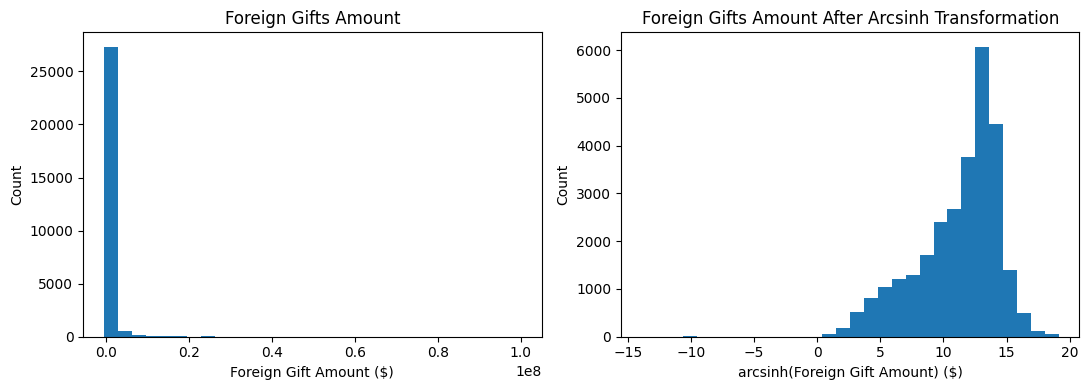

,mean,median,mode,Q1,Q3,max,min
0,588232.717,94615.0,100,5700.0,376142.0,99999999,-537770


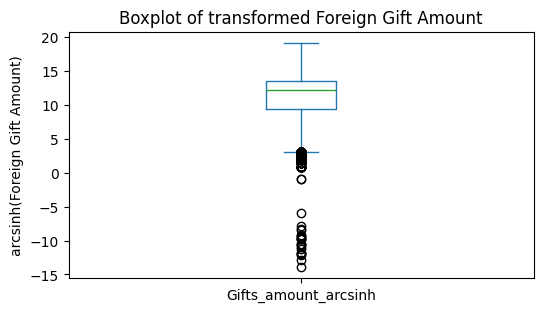




Foreign Gift Amount Variable Description: 
This histogram describes the amount of money spent on gifts (x-axis) and how many times that much money was spent (y-axis).


Foreign Gift Amount Variable Findings: 

Due to the poor scaling of the original graph (had a long tail), the data was scaled with the arcsinh transformation to normalize the distribution.
The histogram with the arcsinh transformed data displays a left-skewed curve, indicating that there was a higher count for instances of more money being spent on gifts. 
The curve peaks around 600k spent (arcsinh(600k) roughly equals 14), with there being around 6000 instances of that much being spent.
Looking at the boxplot, we see the average amount of money spent was $588,232.717, the middle of the distribution for money spent was $946,15.0, 
and 75% of the amount of money spent lies between $5700.0 and $376142.0 (IQR).
There were, however, many outliers. With some abnormally small amounts being spent on gifts, including negativ

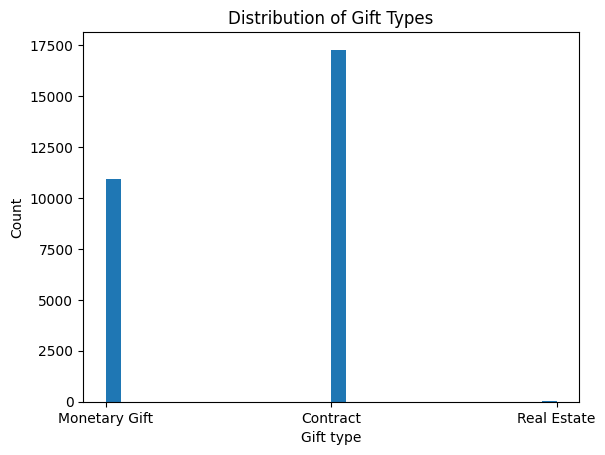




KDE plot of log of foreign gift amount:



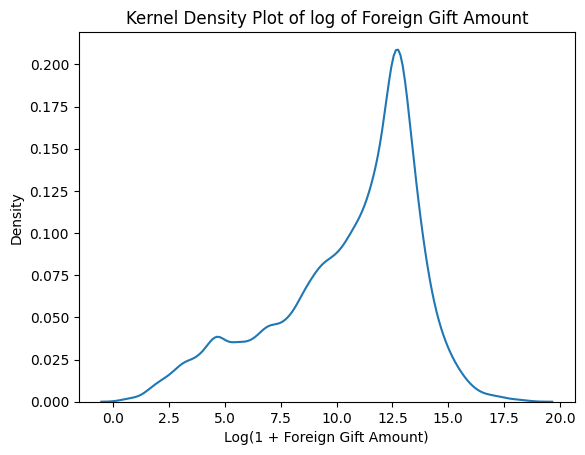




KDE plot of log of foreign gift amount conditional on gift type:



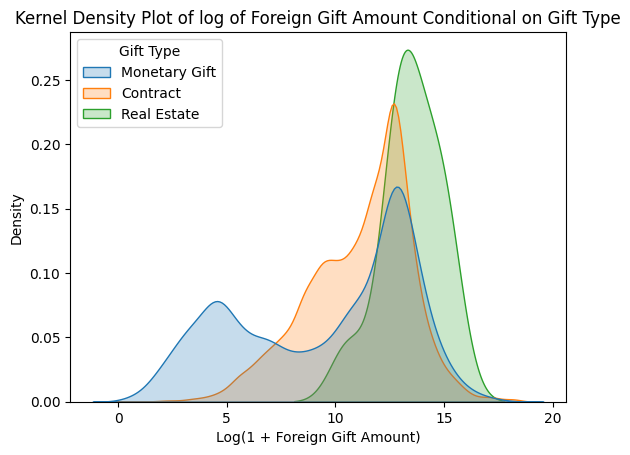




Patterns observed:

Though there were much fewer gifts in the form of real estate, real estate gift types typically related to a higher amount of money spent. 
While most monetary and contract gifts also had a higher amount spent (relatively close behind the peak for real estate expenses), 
these gift types also had a wider distribution with lower amounts of money also was spent - unlike the real estate type. 
Monetary gifts were the most likely to have lower amount spent on gifts, with the plot showing a mini peak around $45 (arcsinh(45) = 4.5)



Top 15 countries in terms of number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype

In [6]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_gifts = pd.read_csv('ForeignGifts_edu.csv')


# Q2.2 - Foreign Gift Amount Histogram, variable description, and findings.

print("Foreign Gift Amount Histogram: \n")

gifts_amount = df_gifts['Foreign Gift Amount']
# Used arcsinh scale for gifts_amount because histogram has a long tail
df_gifts['Gifts_amount_arcsinh'] = np.arcsinh(df_gifts['Foreign Gift Amount'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
gifts_amount.hist(bins=30, grid=False, ax=axes[0])
axes[0].set(title="Foreign Gifts Amount", xlabel="Foreign Gift Amount ($)", ylabel="Count")
df_gifts['Gifts_amount_arcsinh'].hist(bins=30, grid=False, ax=axes[1])
axes[1].set(title="Foreign Gifts Amount After Arcsinh Transformation", xlabel="arcsinh(Foreign Gift Amount) ($)", ylabel="Count")
plt.tight_layout()
plt.show()

print('\n')

amt_summary = pd.DataFrame({
    "mean": [df_gifts["Foreign Gift Amount"].mean()],
    "median": [df_gifts["Foreign Gift Amount"].median()],
    "mode": [df_gifts["Foreign Gift Amount"].mode().iloc[0]],
    "Q1": [df_gifts["Foreign Gift Amount"].quantile(0.25)],
    "Q3": [df_gifts["Foreign Gift Amount"].quantile(0.75)],
    "max": [df_gifts["Foreign Gift Amount"].max()],
    "min": [df_gifts["Foreign Gift Amount"].min()],
})

display(amt_summary.round(3))
df_gifts["Gifts_amount_arcsinh"].plot.box(figsize=(6, 3.2))
plt.title("Boxplot of transformed Foreign Gift Amount")
plt.ylabel("arcsinh(Foreign Gift Amount)")
plt.show()

print('\n')

print("\nForeign Gift Amount Variable Description: \nThis histogram describes the amount of money spent on gifts (x-axis) and how many times that much money was spent (y-axis).\n")

print("""
Foreign Gift Amount Variable Findings:
\nDue to the poor scaling of the original graph (had a long tail), the data was scaled with the arcsinh transformation to normalize the distribution.
The histogram with the arcsinh transformed data displays a left-skewed curve, indicating that there was a higher count for instances of more money being spent on gifts.
The curve peaks around 600k spent (arcsinh(600k) roughly equals 14), with there being around 6000 instances of that much being spent.
Looking at the boxplot, we see the average amount of money spent was $588,232.717, the middle of the distribution for money spent was $946,15.0,
and 75% of the amount of money spent lies between $5700.0 and $376142.0 (IQR).
There were, however, many outliers. With some abnormally small amounts being spent on gifts, including negative amounts being spent in some cases.
These outliers likely lowered the mean, and could have contributed to the mean being lower than the median.
The maximum gift amount was $99999999.

""")

print('\n')

# Q2.3 - Gift Type histogram/value counts table. Proportions of gifts
print('Gift Type value counts table with proportions:\n')
gift_types = df_gifts['Gift Type'].value_counts(normalize = True)
print(gift_types)
print('\n')
print('Gift Type Histogram:\n')
df_gifts['Gift Type'].hist(bins=30, grid=False)
#df_gifts['Gift Type'].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Distribution of Gift Types")
plt.xlabel("Gift type")
plt.ylabel("Count")
plt.show()

print('\n\n')

# Q2.4 - Kernel Density plot of the log of Foreign Gift Amount & log of Forgeign Gift Amount conditional on gift type. Patterns
# In addition to checking affect of outliers on distribution, was recieving a warning because of negative values being passed through the log transform - cleaned data to exclude these values
df_gifts_cleaned = df_gifts[df_gifts['Foreign Gift Amount'] >= 0].copy()
print('KDE plot of log of foreign gift amount:\n')
df_gifts_cleaned['Log_Gift_Amount'] = np.log1p(df_gifts_cleaned['Foreign Gift Amount'])
sns.kdeplot(df_gifts_cleaned['Log_Gift_Amount'])
plt.title('Kernel Density Plot of log of Foreign Gift Amount')
plt.xlabel('Log(1 + Foreign Gift Amount)')
plt.show()
print('\n\n')
print('KDE plot of log of foreign gift amount conditional on gift type:\n')
sns.kdeplot(data = df_gifts_cleaned, x='Log_Gift_Amount', hue = 'Gift Type', fill = True, common_norm = False)
plt.title('Kernel Density Plot of log of Foreign Gift Amount Conditional on Gift Type')
plt.xlabel('Log(1 + Foreign Gift Amount)')
plt.show()
print('\n')
print("""
Patterns observed:

Though there were much fewer gifts in the form of real estate, real estate gift types typically related to a higher amount of money spent.
While most monetary and contract gifts also had a higher amount spent (relatively close behind the peak for real estate expenses),
these gift types also had a wider distribution with lower amounts of money also was spent - unlike the real estate type.
Monetary gifts were the most likely to have lower amount spent on gifts, with the plot showing a mini peak around $45 (arcsinh(45) = 4.5)
""")
print('\n')

# Q2.5 - Top 15 countries in terms of number of gifts & in terms of amount given
#num_gifts = df_gifts.groupby('Country of Giftor').size()
num_gifts = df_gifts['Country of Giftor'].value_counts()
num_top_15_countries = num_gifts.sort_values(ascending = False).head(15)
print('Top 15 countries in terms of number of gifts:')
print(num_top_15_countries)
print('\n')

amnt_given = df_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
amnt_top_15_countries = amnt_given.sort_values(ascending = False).head(15)
print('Top 15 countries in terms of amount given:')
print(amnt_top_15_countries)
print('\n')

# Q2.6 - Which giftors provide the most money in total

giftors = df_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum()
top_giftor = giftors.sort_values(ascending = False).head(3)
print('Top three giftors/institutions that provided the most money, and how much they provided in total:')
print(top_giftor)


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Looking over the AI suggestions, the main improvements to the code were basic fixes that were akin to proofreading - like updating the title, not mixing up the arcsinh and log1p transforms, and other small fixes or adjustments. There weren't many suggestions to improve the code per say, most of them were just for refining and readability - which is still helpful. Most limitations from their suggestions stemmed from the AI possibly not being able to see the actual output of the original or its code, or not being given enough information or context. For instance, the AI said some things in the original would cause errors, but they didn't on my end, so I left it as is. Thus, I think better prompting with more information, guidance, more specific questions, and follow-ups would improve the suggestions. Overall, making sure to test the AI code to make sure the output aligns with your expectations, and knowing that how you prompt the AI is crucial to the quality of its outputs.